In [1]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder 
from sklearn.preprocessing import RobustScaler, StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
import optuna

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

import keras
from scikeras.wrappers import KerasClassifier

#from sklearn.tree import DecisionTreeClassifier
#from sklearn.neighbors import KNeighborsClassifier
#from sklearn.neural_network import MLPClassifier
#from sklearn.linear_model import LogisticRegression
#from sklearn.svm import SVC

In [2]:
df_train = pd.read_csv('data/train.csv', index_col='id')
df_test = pd.read_csv('data/test.csv', index_col='id')

df_train.shape, df_test.shape

((11504798, 11), (7669866, 10))

In [9]:
# make column names all lowercase
df_train.rename(columns=lambda col : col.lower(), inplace=True)
df_test.rename(columns=lambda col : col.lower(), inplace=True)

df_train.head(10)

,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
id,,,,,,,,,,,
0,Male,21,1,35.0,0,1-2 Year,Yes,65101.0,124.0,187,0
1,Male,43,1,28.0,0,> 2 Years,Yes,58911.0,26.0,288,1
2,Female,25,1,14.0,1,< 1 Year,No,38043.0,152.0,254,0
3,Female,35,1,1.0,0,1-2 Year,Yes,2630.0,156.0,76,0
4,Female,36,1,15.0,1,1-2 Year,No,31951.0,152.0,294,0
5,Female,31,1,47.0,1,< 1 Year,No,28150.0,152.0,197,0
6,Male,23,1,45.0,1,< 1 Year,No,27128.0,152.0,190,0
7,Female,47,1,8.0,0,1-2 Year,Yes,40659.0,26.0,262,1
8,Female,26,1,28.0,1,< 1 Year,No,31639.0,152.0,36,0


In [10]:
# we know that there is one datapoint with a non-integer 'region_code' value, so we will drop it
drop_idx = df_train.loc[df_train['region_code'] == 39.2].index[0]
df_train.drop(index=drop_idx, inplace=True)
df_train.reset_index(drop=True, inplace=True)

In [11]:
df_train.shape

(11504797, 11)

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential

In [13]:
# set seed
RANDOM_STATE = 2112
np.random.seed(RANDOM_STATE)

In [14]:
TARGET = 'response'

# we treat every feature like a categorical, and thus encode all of them 
cont_features = []    
cat_features = ['gender', 'driving_license', 'previously_insured', 'vehicle_age', 'vehicle_damage', 
                'policy_sales_channel', 'region_code', 'age', 'vintage', 'annual_premium']

all_data = pd.concat([df_train, df_test])

# apply ordinal encoding to all features (excluding target variable) and set their values to 'int' dtype
# NOTE: we run fit_transform() on combined training and test dataset 
    # this means the ordinal encoder encounters and encodes all unique values in every feature of both train and test sets
    # if we fit only on train, then transform() on test could result in error
ord_enc = OrdinalEncoder()
all_data[cat_features] = ord_enc.fit_transform(all_data.filter(cat_features)).astype('int')

# keep track of cardinality (i.e. number of unique vals) for each feature
feature_cardinality = {}
for feature in cat_features:
    feature_cardinality[feature] = all_data[feature].max() + 1

# after the encoding, we now want to treat the binary features like continuous variables
# while all other features will be sent as input to an embedding layer (essentially one-hot encoding)
cont_features = ['gender', 'driving_license', 'previously_insured', 'vehicle_damage']
cat_features = ['vehicle_age', 'policy_sales_channel', 'region_code', 'age', 'vintage', 'annual_premium']

# split rows in all_data back into separate train and test sets
    # do this based on whether or not a given row has a not-null value in 'response' column
train_data = all_data.query(f"not {TARGET}.isna()")
test_data  = all_data.query(f"{TARGET}.isna()").drop(columns=[TARGET])

features = cont_features + cat_features

# use garbage collector to free up memory
all_data = None
import gc
gc.collect()

26

## NOTE
- from this point on: 
    - **cont_features** is a list containing binary features' names (gender, license, etc.)
    - **cat_features** has all other features' names (i.e. cat features with multiple categories and numerical features)

In [15]:
feature_cardinality

# since we applied ordinal encoding to all features, some numerical ones (vintage, annual_premium) have very large number of unique vals

{'gender': 2,
 'driving_license': 2,
 'previously_insured': 2,
 'vehicle_age': 3,
 'vehicle_damage': 2,
 'policy_sales_channel': 154,
 'region_code': 53,
 'age': 66,
 'vintage': 290,
 'annual_premium': 53958}

In [16]:
# check the results of our encoding on the training data
train_data.filter(features).describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
gender,11504797.0,0.541351,0.498287,0.0,0.0,1.0,1.0,1.0
driving_license,11504797.0,0.998022,0.044431,0.0,1.0,1.0,1.0,1.0
previously_insured,11504797.0,0.462997,0.498629,0.0,0.0,0.0,1.0,1.0
vehicle_damage,11504797.0,0.502680,0.499993,0.0,0.0,1.0,1.0,1.0
vehicle_age,11504797.0,0.521530,0.576739,0.0,0.0,0.0,1.0,2.0
policy_sales_channel,11504797.0,106.972225,51.161584,0.0,28.0,143.0,144.0,153.0
region_code,11504797.0,26.418689,12.991590,0.0,15.0,28.0,35.0,52.0
age,11504797.0,18.383565,14.993458,0.0,4.0,16.0,29.0,65.0
vintage,11504797.0,153.897752,79.979530,0.0,89.0,156.0,222.0,289.0
annual_premium,11504797.0,16250.794763,11626.913583,0.0,8675.0,15221.0,22848.0,53957.0


In [17]:
# we will define a custom "mish" function (Self Regularized Non-Monotonic Activation Function)
    # https://github.com/digantamisra98/Mish
    # https://www.kaggle.com/code/imokuri/mish-activation-function

from tensorflow.keras.layers import Activation
from tensorflow.keras.utils import get_custom_objects

class Mish(Activation):
    '''
    Mish Activation Function.
    .. math::
        mish(x) = x * tanh(softplus(x)) = x * tanh(ln(1 + e^{x}))
    Shape:
        - Input: Arbitrary. Use the keyword argument `input_shape`
        (tuple of integers, does not include the samples axis)
        when using this layer as the first layer in a model.
        - Output: Same shape as the input.
    Examples:
        >>> X = Activation('Mish', name="conv1_act")(X_input)
    '''

    def __init__(self, activation, **kwargs):
        super(Mish, self).__init__(activation, **kwargs)
        self.__name__ = 'Mish'


def mish(inputs):
    return inputs * tf.math.tanh(tf.math.softplus(inputs))

get_custom_objects().update({'Mish': Mish(mish)})

In [18]:
# next, build the model architecture

def build_model(cat_features, cont_features):
    # for each feature in cat_features, we create a separate Input layer 
        # they are all put into a list
    # all features in cont_features are bundled into their own single Input layer
    cat_inputs = [layers.Input(shape=(1,), name=f'cat{i}') for i in range(len(cat_features))]
    cont_inputs = layers.Input(shape=(len(cont_features),))
                                
    # for each layer in cat_inputs, run the layer output through embedding, dropout and flatten layers
    # keep them all in a list so that they can be concatenated later
    flat_embeddings = []
    for i, f in enumerate(cat_features):
        input_dim = int(feature_cardinality[f])
        output_dim = int(min(64, round(1.6 * input_dim ** .56))) # based on the fastai library
        embedding = layers.Embedding(input_dim=input_dim, output_dim=output_dim)(cat_inputs[i])
            # input_dim denotes vocab size (i.e. number of categories for given feature) we can get this value from feature's cardinality
            # output_dim denotes the number of elements in the resulting embedding vectors
                # we set the limit at 64 (for cont features like 'annual_premium', their values will be embedded to 64-element vectors)
        embedding = layers.SpatialDropout1D(.3)(embedding)
        flat_embeddings.append(layers.Flatten()(embedding))
                                
    # concat all flat_embedding layers (AND the cont_input layer), and then normalize
    concatenated_inputs = layers.Concatenate()(flat_embeddings + [cont_inputs, ])
        # we're bringing together all the features now that they've gone through the necessary preprocessing  
    concatenated_inputs_bn = layers.BatchNormalization()(concatenated_inputs)

    # run thru dense and normalization layers -> this output is concatenated with a skip connection to concatenated_inputs_bn
    # after that, another sequence of dense, dropout, normalization
    x = layers.Dense(256, activation='Mish')(concatenated_inputs_bn)
    x = layers.BatchNormalization()(x)
    for units in (128,):
        inp = layers.Concatenate()([x, concatenated_inputs_bn])
        x = layers.Dense(units=units, activation='Mish')(inp)
        x = layers.Dropout(.3)(x)
        x = layers.BatchNormalization()(x)

    # output layer -> 1 unit and sigmoid means we get predicted P(y=1) as model output
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(cat_inputs + [cont_inputs], outputs)

epochs = 4
callbacks = []

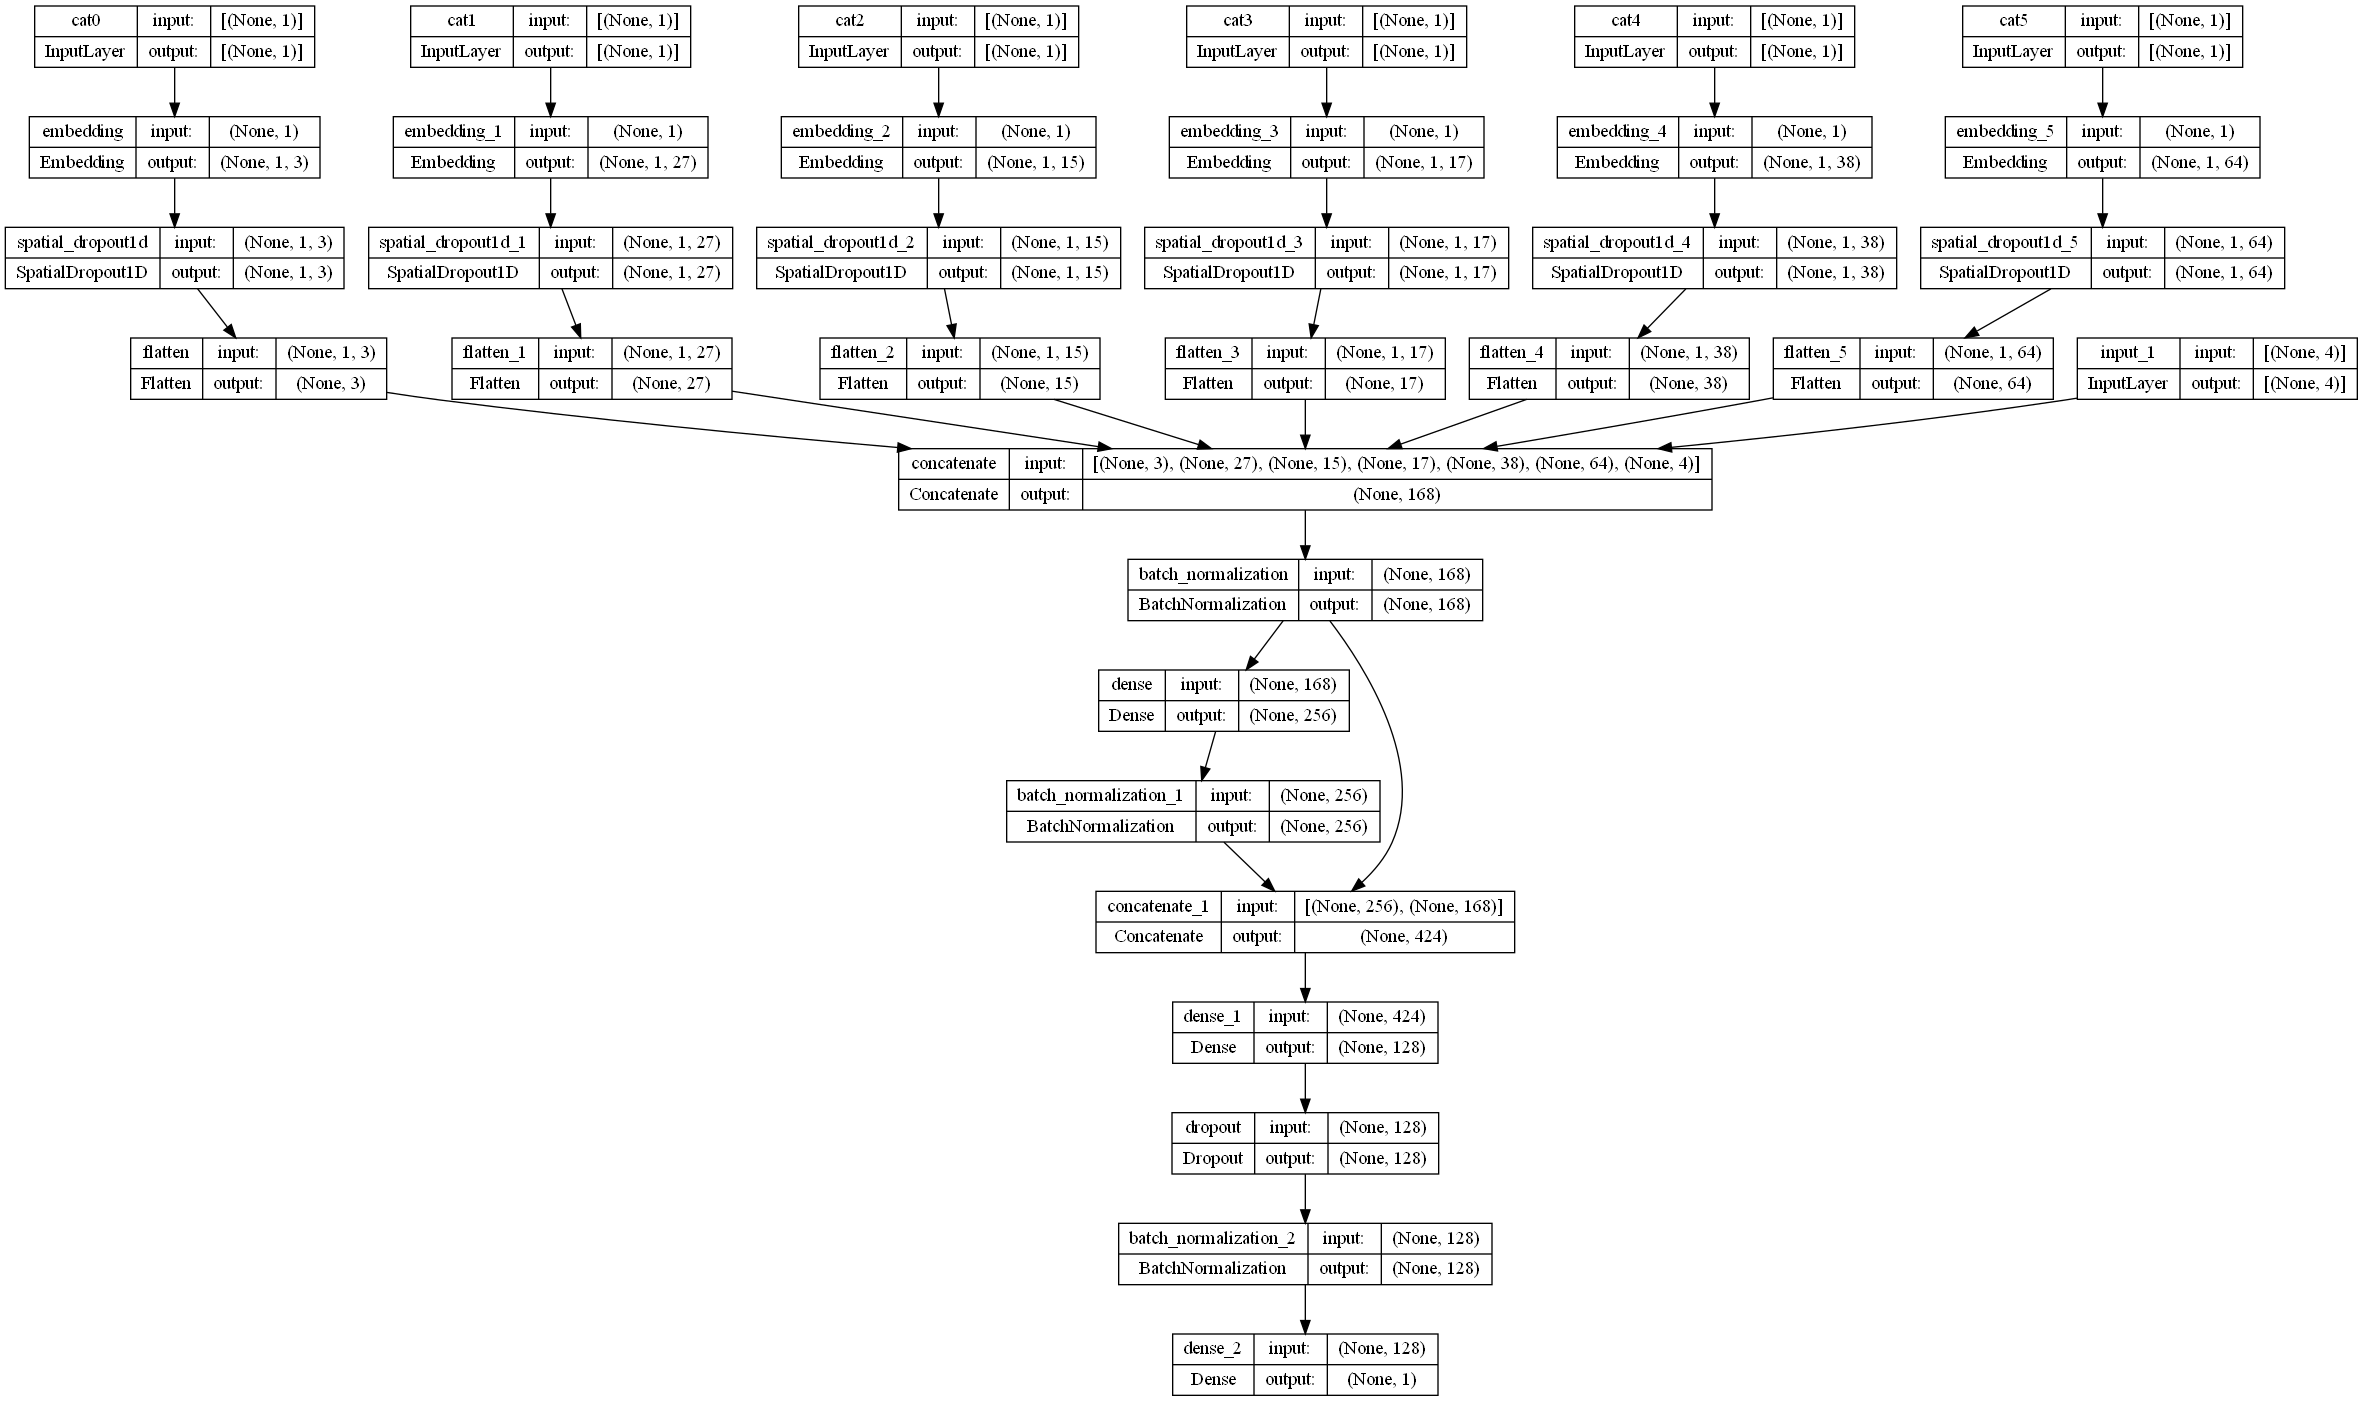

In [19]:
# visualize model architecture

tf.keras.utils.plot_model(
    model=build_model(cat_features, cont_features), 
    show_shapes=True, 
    rankdir='TB')

In [ ]:
# when feeding the data to our NN, we feed the categorical features column-by-column
# while the continuous features are fed as one lump
cat_idxs= []
cont_idxs = []
for f in cat_features:
    cat_idxs.append([features.index(f)])
for f in cont_features:
    cont_idxs.append(features.index(f))
    
feature_idxs = cat_idxs + [cont_idxs]
    # we get list of lists: [[4], [5], [6], [7], [8], [9], [0, 1, 2, 3]]
    # indices of each cat feature is separate list, while cont features are grouped together

def prep_to_feed(df):
    X = df[features].values
    prepped = []
    for i in feature_idxs:
        prepped.append(X[:, i])
    return prepped

# fit_fold() will fit the model to the train set, and then predict for val and test sets
# it also calculates the val AUC score, and finally returns all 3 things
def fit_fold(train, val, test):

    model = build_model(cat_features, cont_features)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1E-4),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC()])

    history = model.fit(
          prep_to_feed(train), train[TARGET],
          validation_data=(prep_to_feed(val), val[TARGET]),
          batch_size=BS,
          epochs=epochs,
          callbacks=callbacks,
          verbose=0
    )

    val_pred = model.predict(prep_to_feed(val), verbose=0, batch_size=BS).flatten()
    test_pred = model.predict(prep_to_feed(test), verbose=0, batch_size=BS).flatten()
    
    val_metric = roc_auc_score(val[TARGET], val_pred)
    return val_pred, test_pred, val_metric

In [ ]:
N_FOLDS = 5
BS = 1024

val_preds = np.zeros(len(train_data))
test_preds = np.zeros(len(test_data))
val_metrics = []

keras.utils.set_random_seed(RANDOM_STATE)
k_fold = StratifiedKFold(n_splits=N_FOLDS, random_state=RANDOM_STATE, shuffle=True)
for i, (train_idx, val_idx) in enumerate(k_fold.split(train_data, train_data[TARGET])):
    fold_train = train_data.loc[train_idx]
    fold_val = train_data.loc[val_idx]

    val_pred, test_pred, val_metric = fit_fold(fold_train, fold_val, test_data)
    
    print(f'  -- fold {i} auc: {val_metric:2.4f}')
    val_metrics.append(val_metric)
    val_preds[val_idx] += val_pred
        # with each fold we will get predictions for 1/5 of the training data
    test_preds += test_pred / N_FOLDS
        # each fold predicts for full test set
        # to get average prediction over all 5 folds, divide the fold predictions by 5 so that each fold essentially has 0.2 weight coef

overall_val_metric = roc_auc_score(train_data[TARGET], val_preds)
print(f'  ----------- {overall_val_metric:2.4f}')